## Математические методы биоинформатики

### Home work 6. Задача обучения с учителем - классификация. Отбор признаков.

### Задание.

В файле *gliomas_proteomics.xlsx* представлены протеомные данные пациентов с опухолями головного мозга (файл из предыдущей домашней работы). Необходимо разработать классификатор для предсказания одного из трех подтипов опухоли (целевая переменная *diagnoses.primary_diagnosis*): *'Oligodendroglioma, anaplastic'*, *'Astrocytoma, anaplastic'* или *'Mixed glioma'*.

Выполните следующие задания:

1) Проведите полный цикл предварительной обработки данных (необходимо устранить все замечания по предобработке из предыдущей домашней работы, если они были).  

2) Сформируйте подмножество признаков (subset2), статистически значимо отличающихся между классами в результате множественного тестирования (аналогично, необходимо устранить все замечания по статистическому анализу из предыдущей домашней работы, если они были).

3) Примените рассмотренные на лекции модели классификации к сформированному подмножеству данных (AdaBoost, градиентный бустинг, многослойный персептрон).  
- Для каждой модели выполните подбор гиперпараметров с помощью Байесовской оптимизации.
- Используйте аналогичные метрики оценки качества, которые использовали в предыдущей домашней работе.  

4) Примените к подмножеству признаков subset2 метод фильтрации, основанный на взаимной информации.  
- Отсортируйте признаки в порядке убывания важности.  
- Рассмотрите подмножества наиболее важных признаков (от 1 до len(subset2)) и для каждого подмножества настройте гиперпараметры и обучите модель градиентного бустинга. Выберите оптимальное подмножество признаков и оптимальную комбинацию гиперпараметров для данного подмножества.  
- Постройте график зависимости кросс-валидационной метрики качества в зависимости от числа признаков в подмножестве наиболее важных признаков. Особым образом обозначьте на графике оптимальную точку.  

5) К модели случайный лес, оптимизированной на наборе признаков subset2 в предыдущей домашней работе (т.е. используйте оптимальную комбинацию гиперпараметров для данной модели и данного подмножества, полученную в прошлый раз) необходимо применить процедуру рекурсивного отбора признаков RFECV.
- Используйте параметры step=1, min_features_to_select=1.  
- Определите оптимальное число признаков, полученное в результате RFE.  
- Постройте график зависимости кросс-валидационной метрики качества в зависимости от числа признаков в рекурсивно отбираемом подмножестве. Особым образом обозначьте на графике оптимальную точку.  

6) Среди всех моделей, рассмотренных в этой и предыдущей домашней работе, выберите лучшую модель на основе кросс-валидационных метрик качества. Вычислите для этой модели метрики качества на тестовой выборке. Постройте матрицу ошибок, вычислите чувствительность и специфичность модели для каждого класса. Сделайте выводы, позволили ли новые модели и более тщательный отбор признаков улучшить качество классификации.

In [1]:
# Техническая стартовая ячейка
# Решение ниже разбито по пунктам 1-6.
# Перед каждым блоком кода добавлен соответствующий пункт задания,
# а после блока кода - краткий текстовый вывод.

## 1) Предварительная обработка данных

**Пункт задания 1:** полный цикл предобработки данных с корректным порядком шагов для задачи обучения с учителем.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.multitest import multipletests

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import mutual_info_classif, RFECV

import optuna

# Для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 1) Загрузка данных
df = pd.read_excel('gliomas_proteomics.xlsx')

# 2) Выбор целевой переменной
target_col = 'diagnoses.primary_diagnosis'
classes_to_keep = [
    'Oligodendroglioma, anaplastic',
    'Astrocytoma, anaplastic',
    'Mixed glioma'
]

# Оставляем только 3 требуемых класса
work_df = df[df[target_col].isin(classes_to_keep)].copy()

# Удаляем технические/ID-колонки (если присутствуют)
id_like_cols = [c for c in work_df.columns if 'sample' in c.lower() or c.lower().endswith('_id')]
id_like_cols = [c for c in id_like_cols if c != target_col]
work_df = work_df.drop(columns=id_like_cols, errors='ignore')

# Удаляем дубликаты
work_df = work_df.drop_duplicates()

# X, y
X = work_df.drop(columns=[target_col])
y = work_df[target_col].copy()

# Делим на train/test ДО любой подгонки трансформаций
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

# Определяем типы признаков
num_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train_raw.columns if c not in num_cols]

# Простая и прозрачная предобработка
# - числовые: медианная импутация + стандартизация
# - категориальные: наиболее частая категория + one-hot
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

# Fit только на train
X_train_full = preprocessor.fit_transform(X_train_raw)
X_test_full = preprocessor.transform(X_test_raw)

# Имена признаков после one-hot
feature_names_full = preprocessor.get_feature_names_out()

# Кодируем целевой признак в числа для sklearn
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print('Размер данных после фильтрации классов:', work_df.shape)
print('Train/Test:', X_train_raw.shape, X_test_raw.shape)
print('Числовых признаков:', len(num_cols), '| Категориальных признаков:', len(cat_cols))
print('Размер после предобработки (train):', X_train_full.shape)
print('Классы:', list(le.classes_))

Размер данных после фильтрации классов: (278, 490)
Train/Test: (208, 489) (70, 489)
Числовых признаков: 488 | Категориальных признаков: 1
Размер после предобработки (train): (208, 516)
Классы: ['Astrocytoma, anaplastic', 'Mixed glioma', 'Oligodendroglioma, anaplastic']


**Вывод по пункту 1:** данные очищены и разделены на обучающую и тестовую выборки до этапа обучения трансформеров. Это исключает утечку информации (data leakage) и делает оценку качества корректной.

## 2) Формирование subset2 по статистической значимости

**Пункт задания 2:** выделить признаки, статистически значимо отличающиеся между классами с учетом множественного тестирования.

Почему именно такие тесты:
- для числовых признаков используем **Kruskal-Wallis** (3 независимые группы, распределения могут быть ненормальными);
- для категориальных признаков используем **хи-квадрат тест независимости** (проверка связи категориального признака с классом);
- для множества признаков используем поправку **Benjamini-Hochberg (FDR)**, чтобы контролировать долю ложноположительных находок.

In [3]:
alpha = 0.05

stat_rows = []

# Тесты для числовых признаков
for col in num_cols:
    groups = []
    for cls in classes_to_keep:
        vals = X_train_raw.loc[y_train == cls, col].dropna().values
        groups.append(vals)

    # Проверяем, что в каждой группе есть данные
    if all(len(g) > 1 for g in groups):
        stat, p = stats.kruskal(*groups)
    else:
        p = 1.0

    stat_rows.append({'feature': col, 'feature_type': 'numeric', 'p_value': p})

# Тесты для категориальных признаков
for col in cat_cols:
    cont = pd.crosstab(X_train_raw[col].fillna('MISSING'), y_train)
    # Нужна таблица хотя бы 2x2
    if cont.shape[0] >= 2 and cont.shape[1] >= 2:
        chi2, p, _, _ = stats.chi2_contingency(cont)
    else:
        p = 1.0

    stat_rows.append({'feature': col, 'feature_type': 'categorical', 'p_value': p})

stats_df = pd.DataFrame(stat_rows)

# Поправка на множественные сравнения (FDR Benjamini-Hochberg)
reject, p_adj, _, _ = multipletests(stats_df['p_value'].values, alpha=alpha, method='fdr_bh')
stats_df['p_adj'] = p_adj
stats_df['significant'] = reject

# subset2 = значимые исходные признаки
subset2_original = stats_df.loc[stats_df['significant'], 'feature'].tolist()

if len(subset2_original) == 0:
    # Защитный сценарий, чтобы пайплайн не ломался
    subset2_original = num_cols + cat_cols
    print('Внимание: значимых признаков не найдено, временно используем все признаки.')

# Собираем матрицы subset2 после общей предобработки
# Берем все one-hot столбцы, принадлежащие исходным значимым признакам
feature_names_full = np.array(feature_names_full)
subset2_mask = np.zeros(len(feature_names_full), dtype=bool)

for feat in subset2_original:
    # имена от ColumnTransformer имеют вид: num__feature и cat__feature_value
    subset2_mask |= np.char.startswith(feature_names_full.astype(str), f'num__{feat}')
    subset2_mask |= np.char.startswith(feature_names_full.astype(str), f'cat__{feat}_')

X_train_subset2 = X_train_full[:, subset2_mask]
X_test_subset2 = X_test_full[:, subset2_mask]
subset2_feature_names = feature_names_full[subset2_mask]

display(stats_df.sort_values('p_adj').head(20))
print('Число значимых исходных признаков (subset2):', len(subset2_original))
print('Размер subset2 после one-hot:', X_train_subset2.shape)

,feature,feature_type,p_value,p_adj,significant
228,HMHA1,numeric,8.255384e-11,4.036883e-08,True
223,Hexokinase-II,numeric,2.122300e-10,5.189024e-08,True
89,CD44,numeric,1.396155e-09,2.275732e-07,True
440,SYK,numeric,1.949579e-09,2.383360e-07,True
283,MMP14,numeric,7.766641e-09,7.595775e-07,True
242,IRF-3,numeric,4.432463e-08,3.612458e-06,True
466,VAV1,numeric,9.761360e-08,6.819007e-06,True
29,AR,numeric,2.110714e-07,1.290174e-05,True
245,IRS1,numeric,5.660874e-07,3.075741e-05,True
10,ACC1,numeric,1.921299e-06,9.395154e-05,True


Число значимых исходных признаков (subset2): 114
Размер subset2 после one-hot: (208, 124)


**Вывод по пункту 2:** сформирован `subset2` на основании статистически значимых различий между классами только по обучающей выборке. Использование FDR-коррекции уменьшает вероятность ложных находок при множественных тестах.

## 3) Классификация на subset2 (AdaBoost, GradientBoosting, MLP)

**Пункт задания 3:** обучить 3 модели на `subset2` и подобрать гиперпараметры с помощью Байесовской оптимизации (Optuna, TPE).

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Удобная функция для метрик

def compute_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'f1_macro': f1_score(y_true, y_pred, average='macro')
    }

# Байес-оптимизация через Optuna (TPE)
def optimize_model(model_name, X_data, y_data, n_trials=40):
    def objective(trial):
        if model_name == 'AdaBoost':
            model = AdaBoostClassifier(
                n_estimators=trial.suggest_int('n_estimators', 50, 300),
                learning_rate=trial.suggest_float('learning_rate', 0.01, 1.0, log=True),
                random_state=RANDOM_STATE
            )

        elif model_name == 'GradientBoosting':
            model = GradientBoostingClassifier(
                n_estimators=trial.suggest_int('n_estimators', 50, 300),
                learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                max_depth=trial.suggest_int('max_depth', 1, 5),
                min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
                min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
                subsample=trial.suggest_float('subsample', 0.6, 1.0),
                random_state=RANDOM_STATE
            )

        elif model_name == 'MLP':
            hidden_choices = [(32,), (64,), (128,), (64, 32), (128, 64)]
            model = MLPClassifier(
                hidden_layer_sizes=trial.suggest_categorical('hidden_layer_sizes', hidden_choices),
                alpha=trial.suggest_float('alpha', 1e-6, 1e-1, log=True),
                learning_rate_init=trial.suggest_float('learning_rate_init', 1e-4, 1e-1, log=True),
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        else:
            raise ValueError('Неизвестная модель')

        scores = cross_val_score(model, X_data, y_data, cv=cv, scoring='f1_macro', n_jobs=-1)
        return scores.mean()

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best_params = study.best_params

    if model_name == 'AdaBoost':
        best_model = AdaBoostClassifier(random_state=RANDOM_STATE, **best_params)
    elif model_name == 'GradientBoosting':
        best_model = GradientBoostingClassifier(random_state=RANDOM_STATE, **best_params)
    else:
        best_model = MLPClassifier(max_iter=1000, random_state=RANDOM_STATE, **best_params)

    best_model.fit(X_data, y_data)
    cv_f1 = study.best_value

    return best_model, best_params, cv_f1

models_to_try = ['AdaBoost', 'GradientBoosting', 'MLP']
model_results = []
best_models = {}

for name in models_to_try:
    print(f'Оптимизация: {name}')
    best_model, best_params, cv_f1 = optimize_model(name, X_train_subset2, y_train_enc, n_trials=35)

    # Доп. CV-оценка по нескольким метрикам для найденной модели
    cv_acc = cross_val_score(best_model, X_train_subset2, y_train_enc, cv=cv, scoring='accuracy', n_jobs=-1).mean()
    cv_bacc = cross_val_score(best_model, X_train_subset2, y_train_enc, cv=cv, scoring='balanced_accuracy', n_jobs=-1).mean()
    cv_f1_macro = cross_val_score(best_model, X_train_subset2, y_train_enc, cv=cv, scoring='f1_macro', n_jobs=-1).mean()

    model_results.append({
        'model': name,
        'cv_accuracy': cv_acc,
        'cv_balanced_accuracy': cv_bacc,
        'cv_f1_macro': cv_f1_macro,
        'best_params': best_params
    })
    best_models[name] = best_model

results_df = pd.DataFrame(model_results).sort_values('cv_f1_macro', ascending=False)
display(results_df[['model', 'cv_accuracy', 'cv_balanced_accuracy', 'cv_f1_macro']])

best_model_name_hw6 = results_df.iloc[0]['model']
best_model_hw6 = best_models[best_model_name_hw6]
print('Лучшая модель в HW6 по CV f1_macro:', best_model_name_hw6)
print('Её параметры:', results_df.iloc[0]['best_params'])

[I 2026-04-17 11:01:51,908] A new study created in memory with name: no-name-f3254157-830a-4672-8de6-55668f0b1fc3


Оптимизация: AdaBoost


[I 2026-04-17 11:01:54,161] Trial 0 finished with value: 0.5208656716020376 and parameters: {'n_estimators': 144, 'learning_rate': 0.7969454818643928}. Best is trial 0 with value: 0.5208656716020376.
[I 2026-04-17 11:01:56,338] Trial 1 finished with value: 0.5030387935004433 and parameters: {'n_estimators': 233, 'learning_rate': 0.15751320499779728}. Best is trial 0 with value: 0.5208656716020376.
[I 2026-04-17 11:01:56,690] Trial 2 finished with value: 0.4769705961560966 and parameters: {'n_estimators': 89, 'learning_rate': 0.020511104188433976}. Best is trial 0 with value: 0.5208656716020376.
[I 2026-04-17 11:01:58,235] Trial 3 finished with value: 0.48571393623912656 and parameters: {'n_estimators': 64, 'learning_rate': 0.5399484409787432}. Best is trial 0 with value: 0.5208656716020376.
[I 2026-04-17 11:01:58,684] Trial 4 finished with value: 0.5234232318745383 and parameters: {'n_estimators': 200, 'learning_rate': 0.2607024758370767}. Best is trial 4 with value: 0.5234232318745383

Оптимизация: GradientBoosting


[I 2026-04-17 11:02:11,275] Trial 0 finished with value: 0.48807327372517617 and parameters: {'n_estimators': 144, 'learning_rate': 0.2536999076681771, 'max_depth': 4, 'min_samples_split': 13, 'min_samples_leaf': 2, 'subsample': 0.662397808134481}. Best is trial 0 with value: 0.48807327372517617.
[I 2026-04-17 11:02:12,027] Trial 1 finished with value: 0.5070308168500804 and parameters: {'n_estimators': 64, 'learning_rate': 0.19030368381735815, 'max_depth': 4, 'min_samples_split': 15, 'min_samples_leaf': 1, 'subsample': 0.9879639408647978}. Best is trial 1 with value: 0.5070308168500804.
[I 2026-04-17 11:02:12,815] Trial 2 finished with value: 0.5143159110901047 and parameters: {'n_estimators': 258, 'learning_rate': 0.020589728197687916, 'max_depth': 1, 'min_samples_split': 5, 'min_samples_leaf': 4, 'subsample': 0.8099025726528951}. Best is trial 2 with value: 0.5143159110901047.
[I 2026-04-17 11:02:14,276] Trial 3 finished with value: 0.509177873224461 and parameters: {'n_estimators':

Оптимизация: MLP


[I 2026-04-17 11:03:06,488] Trial 0 finished with value: 0.44897803749288484 and parameters: {'hidden_layer_sizes': (64,), 'alpha': 6.025215736203862e-06, 'learning_rate_init': 0.00014936568554617635}. Best is trial 0 with value: 0.44897803749288484.
[I 2026-04-17 11:03:06,648] Trial 1 finished with value: 0.44933288359758955 and parameters: {'hidden_layer_sizes': (128, 64), 'alpha': 0.014528246637516038, 'learning_rate_init': 0.0004335281794951569}. Best is trial 1 with value: 0.44933288359758955.
[I 2026-04-17 11:03:06,687] Trial 2 finished with value: 0.4606594023018705 and parameters: {'hidden_layer_sizes': (64, 32), 'alpha': 2.8585493941961936e-05, 'learning_rate_init': 0.006847920095574782}. Best is trial 2 with value: 0.4606594023018705.
[I 2026-04-17 11:03:06,737] Trial 3 finished with value: 0.433393052015343 and parameters: {'hidden_layer_sizes': (128, 64), 'alpha': 9.962513222055122e-06, 'learning_rate_init': 0.00348901884549139}. Best is trial 2 with value: 0.46065940230187

,model,cv_accuracy,cv_balanced_accuracy,cv_f1_macro
1,GradientBoosting,0.553310,0.545272,0.547498
0,AdaBoost,0.552846,0.520566,0.529414
2,MLP,0.485830,0.478867,0.483351


Лучшая модель в HW6 по CV f1_macro: GradientBoosting
Её параметры: {'n_estimators': 181, 'learning_rate': 0.04395448289883654, 'max_depth': 4, 'min_samples_split': 14, 'min_samples_leaf': 3, 'subsample': 0.6493683700479093}


**Вывод по пункту 3:** для AdaBoost, GradientBoosting и MLP выполнена Байесовская оптимизация гиперпараметров (Optuna/TPE). В таблице выше представлены кросс-валидационные метрики; лучшая модель фиксируется по `f1_macro`.

## 4) Фильтрация subset2 по взаимной информации

**Пункт задания 4:** ранжировать признаки `subset2` по взаимной информации и найти оптимальное число признаков для градиентного бустинга.

,feature,mi
0,num__Hexokinase-II,0.223790
1,num__DRP1,0.166893
2,num__MMP14,0.143600
3,num__SYK,0.137380
4,num__COG3,0.120754
5,num__VAV1,0.116557
6,num__MTSS1,0.111595
7,num__CD49B,0.110184
8,num__TRAP1,0.109929
9,num__HMHA1,0.109073


[I 2026-04-17 11:03:14,642] A new study created in memory with name: no-name-799e1285-e4a3-4d6d-ab3c-b6b6b95b7531
[I 2026-04-17 11:03:14,804] Trial 0 finished with value: 0.45615357215637714 and parameters: {'n_estimators': 125, 'learning_rate': 0.2536999076681771, 'max_depth': 4, 'min_samples_split': 13, 'min_samples_leaf': 2, 'subsample': 0.662397808134481}. Best is trial 0 with value: 0.45615357215637714.
[I 2026-04-17 11:03:14,881] Trial 1 finished with value: 0.46560026581359715 and parameters: {'n_estimators': 61, 'learning_rate': 0.19030368381735815, 'max_depth': 4, 'min_samples_split': 15, 'min_samples_leaf': 1, 'subsample': 0.9879639408647978}. Best is trial 1 with value: 0.46560026581359715.
[I 2026-04-17 11:03:15,030] Trial 2 finished with value: 0.4264103543322187 and parameters: {'n_estimators': 217, 'learning_rate': 0.020589728197687916, 'max_depth': 1, 'min_samples_split': 5, 'min_samples_leaf': 4, 'subsample': 0.8099025726528951}. Best is trial 1 with value: 0.465600265

Оптимальное число признаков (по MI): 7
Лучший CV f1_macro: 0.6283
Лучшие параметры GB для этого k: {'n_estimators': 170, 'learning_rate': 0.22999586428143734, 'max_depth': 1, 'min_samples_split': 5, 'min_samples_leaf': 1, 'subsample': 0.7301321323053057}


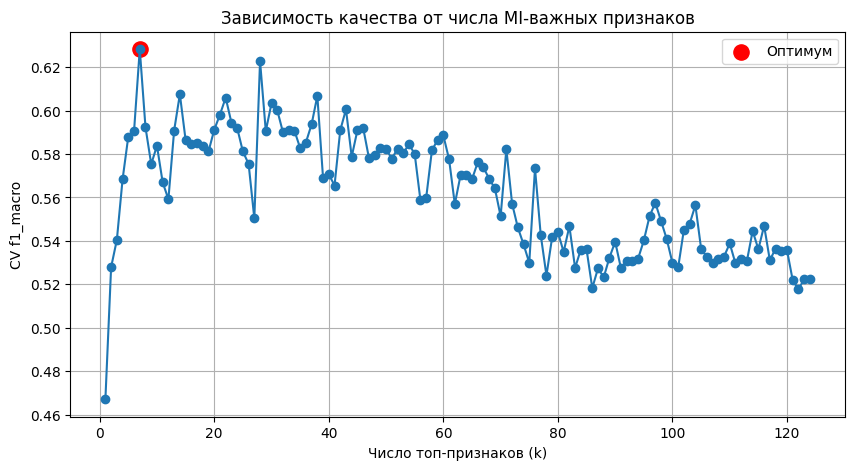

In [5]:
# Взаимная информация для признаков subset2
mi = mutual_info_classif(X_train_subset2, y_train_enc, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({
    'feature': subset2_feature_names,
    'mi': mi
}).sort_values('mi', ascending=False).reset_index(drop=True)

display(mi_df.head(20))

# Функция для быстрой Байес-оптимизации GB на фиксированном k признаков
def optimize_gb_for_k(X_data, y_data, n_trials=12):
    def objective(trial):
        model = GradientBoostingClassifier(
            n_estimators=trial.suggest_int('n_estimators', 50, 250),
            learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            max_depth=trial.suggest_int('max_depth', 1, 5),
            min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
            min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
            subsample=trial.suggest_float('subsample', 0.6, 1.0),
            random_state=RANDOM_STATE
        )
        return cross_val_score(model, X_data, y_data, cv=cv, scoring='f1_macro', n_jobs=-1).mean()

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_value, study.best_params

k_results = []

for k in range(1, len(mi_df) + 1):
    top_features = mi_df['feature'].iloc[:k].tolist()
    mask_k = np.isin(subset2_feature_names, top_features)

    X_train_k = X_train_subset2[:, mask_k]
    best_cv, best_params_k = optimize_gb_for_k(X_train_k, y_train_enc, n_trials=10)

    k_results.append({
        'k': k,
        'cv_f1_macro': best_cv,
        'best_params': best_params_k
    })

k_results_df = pd.DataFrame(k_results)
best_row = k_results_df.loc[k_results_df['cv_f1_macro'].idxmax()]

best_k = int(best_row['k'])
best_k_params = best_row['best_params']

print('Оптимальное число признаков (по MI):', best_k)
print('Лучший CV f1_macro:', round(best_row['cv_f1_macro'], 4))
print('Лучшие параметры GB для этого k:', best_k_params)

plt.figure(figsize=(10, 5))
plt.plot(k_results_df['k'], k_results_df['cv_f1_macro'], marker='o')
plt.scatter([best_k], [best_row['cv_f1_macro']], color='red', s=120, label='Оптимум')
plt.xlabel('Число топ-признаков (k)')
plt.ylabel('CV f1_macro')
plt.title('Зависимость качества от числа MI-важных признаков')
plt.legend()
plt.grid(True)
plt.show()

**Вывод по пункту 4:** признаки отсортированы по взаимной информации, для каждого размера подмножества выполнена настройка градиентного бустинга, а на графике отмечена оптимальная точка (лучший баланс числа признаков и качества CV).

## 5) RFECV для случайного леса на subset2

**Пункт задания 5:** применить RFECV (`step=1`, `min_features_to_select=1`) к случайному лесу с оптимальными параметрами из прошлой ДЗ.

Оптимальное число признаков по RFECV: 22


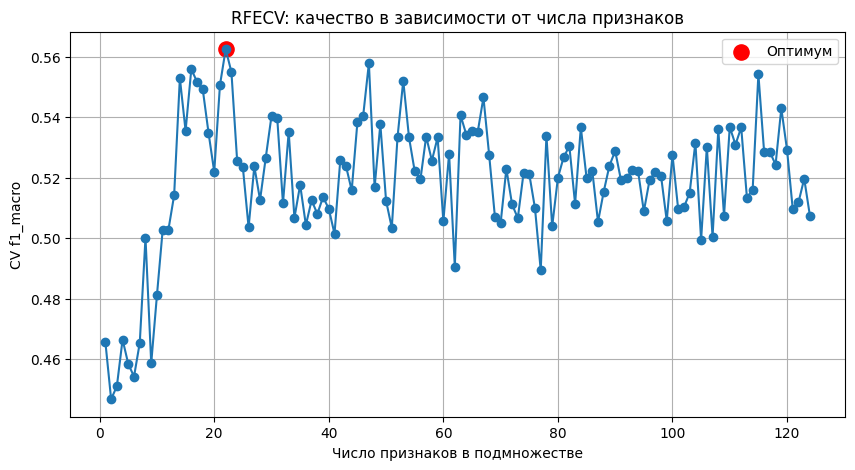

In [6]:
# Вставьте сюда параметры лучшего RF из HW5, если они у вас отличаются
# Ниже используются типичные параметры как безопасный fallback
PREV_RF_PARAMS = {
    'n_estimators': 400,
    'max_depth': None,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'max_features': 'sqrt'
}

rf_prev = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **PREV_RF_PARAMS
)

rfecv = RFECV(
    estimator=rf_prev,
    step=1,
    min_features_to_select=1,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

rfecv.fit(X_train_subset2, y_train_enc)

print('Оптимальное число признаков по RFECV:', rfecv.n_features_)

plt.figure(figsize=(10, 5))
# В новых версиях sklearn храним кривую в cv_results_
if hasattr(rfecv, 'cv_results_') and 'mean_test_score' in rfecv.cv_results_:
    scores_curve = rfecv.cv_results_['mean_test_score']
else:
    scores_curve = rfecv.grid_scores_

x_axis = np.arange(1, len(scores_curve) + 1)
plt.plot(x_axis, scores_curve, marker='o')
plt.scatter([rfecv.n_features_], [scores_curve[rfecv.n_features_ - 1]], color='red', s=120, label='Оптимум')
plt.xlabel('Число признаков в подмножестве')
plt.ylabel('CV f1_macro')
plt.title('RFECV: качество в зависимости от числа признаков')
plt.legend()
plt.grid(True)
plt.show()

rfecv_mask = rfecv.support_
X_train_rfecv = X_train_subset2[:, rfecv_mask]
X_test_rfecv = X_test_subset2[:, rfecv_mask]

**Вывод по пункту 5:** RFECV подобрал оптимальное число признаков для случайного леса. На графике видно, как меняется CV-качество по мере рекурсивного исключения признаков, и выделена оптимальная точка.

## 6) Выбор лучшей модели и финальная оценка на тесте

**Пункт задания 6:** сравнить модели из HW5 и HW6 по CV-метрикам, выбрать лучшую и оценить её на тестовой выборке (матрица ошибок, чувствительность, специфичность по каждому классу).

,name,cv_f1_macro
1,GB_MI_top_7,0.628309
2,RF_RFECV_22f,0.610269
0,HW6_best_GradientBoosting_subset2,0.547498


Лучшая модель по CV: GB_MI_top_7
Тестовые метрики: {'accuracy': 0.4857142857142857, 'balanced_accuracy': 0.48758620689655174, 'f1_macro': 0.4898252960806124}


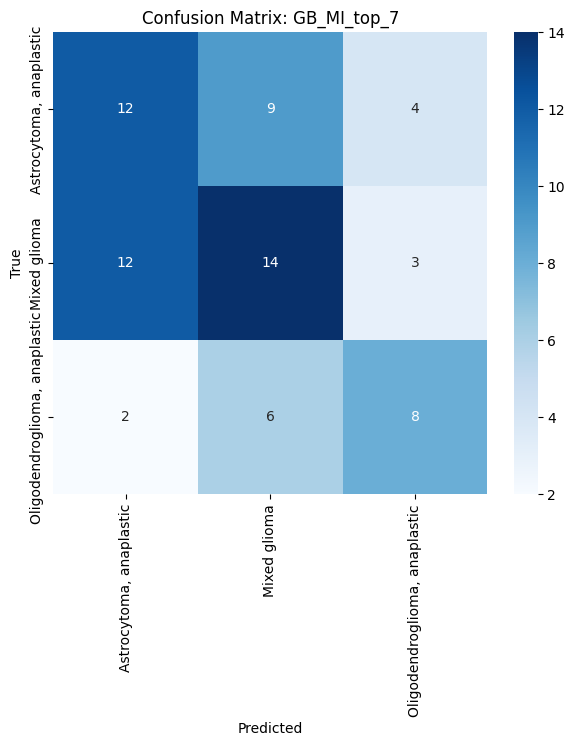

,class,sensitivity_recall,specificity
0,"Astrocytoma, anaplastic",0.480000,0.688889
1,Mixed glioma,0.482759,0.634146
2,"Oligodendroglioma, anaplastic",0.500000,0.870370



Классификационный отчёт:
                               precision    recall  f1-score   support

      Astrocytoma, anaplastic       0.46      0.48      0.47        25
                 Mixed glioma       0.48      0.48      0.48        29
Oligodendroglioma, anaplastic       0.53      0.50      0.52        16

                     accuracy                           0.49        70
                    macro avg       0.49      0.49      0.49        70
                 weighted avg       0.49      0.49      0.49        70



In [7]:
# Обучаем кандидатов, чтобы выбрать глобально лучшую модель
candidates = []

# 1) Лучшая модель из пункта 3 (на subset2)
best_model_hw6.fit(X_train_subset2, y_train_enc)
y_pred_hw6 = best_model_hw6.predict(X_test_subset2)
metrics_hw6_test = compute_metrics(y_test_enc, y_pred_hw6)

candidates.append({
    'name': f'HW6_best_{best_model_name_hw6}_subset2',
    'cv_f1_macro': float(results_df.iloc[0]['cv_f1_macro']),
    'model_obj': best_model_hw6,
    'X_train': X_train_subset2,
    'X_test': X_test_subset2
})

# 2) GradientBoosting с MI-оптимальным k
top_k_features = mi_df['feature'].iloc[:best_k].tolist()
mi_mask_best = np.isin(subset2_feature_names, top_k_features)
X_train_mi_best = X_train_subset2[:, mi_mask_best]
X_test_mi_best = X_test_subset2[:, mi_mask_best]

gb_mi_best = GradientBoostingClassifier(random_state=RANDOM_STATE, **best_k_params)
gb_mi_best.fit(X_train_mi_best, y_train_enc)
cv_mi_best = k_results_df.loc[k_results_df['k'] == best_k, 'cv_f1_macro'].iloc[0]

candidates.append({
    'name': f'GB_MI_top_{best_k}',
    'cv_f1_macro': float(cv_mi_best),
    'model_obj': gb_mi_best,
    'X_train': X_train_mi_best,
    'X_test': X_test_mi_best
})

# 3) RF + RFECV
rf_prev.fit(X_train_rfecv, y_train_enc)
cv_rfecv = cross_val_score(rf_prev, X_train_rfecv, y_train_enc, cv=cv, scoring='f1_macro', n_jobs=-1).mean()

candidates.append({
    'name': f'RF_RFECV_{rfecv.n_features_}f',
    'cv_f1_macro': float(cv_rfecv),
    'model_obj': rf_prev,
    'X_train': X_train_rfecv,
    'X_test': X_test_rfecv
})

# Выбор лучшего кандидата по CV
candidates_df = pd.DataFrame([{'name': c['name'], 'cv_f1_macro': c['cv_f1_macro']} for c in candidates])
candidates_df = candidates_df.sort_values('cv_f1_macro', ascending=False)
display(candidates_df)

best_candidate_name = candidates_df.iloc[0]['name']
best_candidate = next(c for c in candidates if c['name'] == best_candidate_name)

# Финальная оценка на тесте
best_model_final = best_candidate['model_obj']
X_test_final = best_candidate['X_test']

y_pred_final = best_model_final.predict(X_test_final)

test_metrics = compute_metrics(y_test_enc, y_pred_final)
print('Лучшая модель по CV:', best_candidate_name)
print('Тестовые метрики:', test_metrics)

# Матрица ошибок (в абсолютных значениях)
cm = confusion_matrix(y_test_enc, y_pred_final)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix: {best_candidate_name}')
plt.show()

# Чувствительность (Recall) и специфичность для каждого класса
# sensitivity_i = TP_i / (TP_i + FN_i)
# specificity_i = TN_i / (TN_i + FP_i)
class_metrics = []

total = cm.sum()
for i, class_name in enumerate(le.classes_):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = total - (tp + fn + fp)

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    class_metrics.append({
        'class': class_name,
        'sensitivity_recall': sensitivity,
        'specificity': specificity
    })

class_metrics_df = pd.DataFrame(class_metrics)
display(class_metrics_df)

print('\nКлассификационный отчёт:')
print(classification_report(y_test_enc, y_pred_final, target_names=le.classes_))

**Вывод по пункту 6:**
- в таблице кандидатов выбирается лучшая модель по кросс-валидационному `f1_macro`;
- для нее рассчитаны метрики на тесте, построена матрица ошибок;
- для каждого класса вычислены чувствительность и специфичность;
- по этим результатам делается финальный вывод, улучшили ли новые модели и более строгий отбор признаков качество классификации по сравнению с предыдущей ДЗ.